In [1]:
import numpy as np

BOUNDARY_VOLUME = 10000 * 10000 * 10000
CYLINDER_VOLUME = np.pi * np.power(30, 2) * 5000

VOLUME_RATIO = np.array([0.005, 0.006, 0.007, 0.01])
n_cylinders = np.round(BOUNDARY_VOLUME * VOLUME_RATIO / CYLINDER_VOLUME).astype(int)
print(n_cylinders)

[354 424 495 707]


## 第二问：独立均匀随机蒙特卡洛模型

题目只说明介质 A 可以处于“任意位置、任意方向”，没有指定概率分布。为使导通概率具有确定含义，采用以下独立均匀模型：

\[
\boldsymbol c_i\overset{\mathrm{iid}}{\sim}U([-5000,5000)^3),\qquad
\boldsymbol u_i\overset{\mathrm{iid}}{\sim}U(S^2),
\]

其中圆柱轴中点 \(\boldsymbol c_i\) 在立方体内均匀分布，轴方向 \(\boldsymbol u_i\) 在单位球面上各向同性；不同圆柱、不同试验相互独立。代码用三维标准正态向量归一化生成 \(\boldsymbol u_i\)，而不是令球坐标极角均匀。题目允许介质相互贯穿，因此不做碰撞拒绝。

第二问严格采用三轴均为 \([-5000,5000]\) nm 的题面边界。每根长度 5000 nm、半径 30 nm 的完整圆柱先按周期规则搬运并与基本盒求交：

\[
F_{i,k}=\bigl(C_i-k\odot(10000,10000,10000)\bigr)\cap[-5000,5000]^3.
\]

所有非空 \(F_{i,k}\) 都作为独立导体节点；`parent_id` 只记录来源，同源碎片不会自动并入并查集。裁剪后只计算盒内直接欧氏距离，不再做第二次周期镜像。这样不会因为一根原圆柱跨过左右边界，就把左右两个已分离碎片误判为导通。

圆柱数量按名义体积分数计算：

\[
N=\operatorname{round}\!\left(\frac{\phi\,10000^3}{\pi\,30^2\,5000}\right),
\]

四种体积分数分别对应 354、424、495、707 根完整圆柱。一次试验生成最多 707 根 iid 圆柱，并用前 354/424/495/707 根作为四档共同随机数前缀；每一档的边际分布与单独独立生成完全相同，试验之间仍相互独立。

In [2]:
from dataclasses import dataclass
from itertools import combinations, product
import math
import time

import numpy as np
import pandas as pd
from scipy.optimize import minimize

BOX_HALF = 5000.0
BOX_MIN = np.full(3, -BOX_HALF)
BOX_MAX = np.full(3, BOX_HALF)
PERIOD = np.full(3, 2.0 * BOX_HALF)
LENGTH = 5000.0
RADIUS = 30.0
THRESHOLD = 1.8
NUM_TOL = 1e-5
FEAS_TOL = 2e-7
SUPPORT_FEAS_TOL = 1e-9
CONTACT_LIMIT = THRESHOLD + NUM_TOL
SUPPORT_STABILITY_NM = 1e-5
NEAR_THRESHOLD_TOL = 1e-4
GJK_GAP_TOL = 1e-5
GJK_FAR_GUARD = 1e-2

## 真实裁剪碎片与纯原问题支持函数

下面直接在“有限圆柱与立方体的交集”上求支持点，不把斜切碎片封成普通小圆柱，也不使用截断多面体、胶囊或对偶证书。

支持函数采用三变量 SLSQP 原问题。完整圆柱解析极值点落在盒内时直接返回；否则依次使用完整圆柱极值、已知可行点、盒投影点，必要时再用 Dykstra 投影点重算。每个数值候选在比较目标值前都先用 Dykstra 恢复到 \(10^{-9}\) nm 可行精度，从而避免“轻微越界点”虚增支持值；回退时始终保留严格可行候选中的最大值，并要求两个独立初值的支持值在 \(10^{-5}\) nm 内稳定，否则明确抛错。

In [3]:
class DynamicUnionFind:
    def __init__(self):
        self.parent = []
        self.rank = []

    def add(self):
        index = len(self.parent)
        self.parent.append(index)
        self.rank.append(0)
        return index

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        a, b = self.find(a), self.find(b)
        if a == b:
            return False
        if self.rank[a] < self.rank[b]:
            a, b = b, a
        self.parent[b] = a
        if self.rank[a] == self.rank[b]:
            self.rank[a] += 1
        return True

    def connected(self, a, b):
        return self.find(a) == self.find(b)


class Cylinder:
    def __init__(self, p, q, radius=RADIUS):
        self.p = np.asarray(p, float)
        self.q = np.asarray(q, float)
        self.radius = float(radius)
        v = self.q - self.p
        self.length = float(np.linalg.norm(v))
        if self.length <= 1e-12:
            raise ValueError("cylinder axis must have positive length")
        self.u = v / self.length
        self.center = 0.5 * (self.p + self.q)
        self.h = 0.5 * self.length
        extent = self.h * np.abs(self.u) + self.radius * np.sqrt(np.maximum(0.0, 1.0-self.u**2))
        self.aabb_min = self.center - extent
        self.aabb_max = self.center + extent

    def translated(self, shift):
        return Cylinder(self.p + shift, self.q + shift, self.radius)

    def support(self, direction):
        d = np.asarray(direction, float)
        axial = float(d @ self.u)
        radial = d - axial * self.u
        radial_norm = float(np.linalg.norm(radial))
        point = self.center + (self.h if axial >= 0 else -self.h) * self.u
        if radial_norm > 1e-14:
            point = point + self.radius * radial / radial_norm
        return point


def orthobasis(u):
    u = np.asarray(u, float)
    helper = np.eye(3)[int(np.argmin(np.abs(u)))]
    v = np.cross(u, helper)
    v /= np.linalg.norm(v)
    w = np.cross(u, v)
    return np.column_stack((u, v, w))


def axis_segment_in_box(cylinder, lo, hi):
    t0, t1 = -cylinder.h, cylinder.h
    for j in range(3):
        uj = float(cylinder.u[j])
        if abs(uj) <= 1e-14:
            if not (lo[j]-1e-8 <= cylinder.center[j] <= hi[j]+1e-8):
                return None
            continue
        a = (lo[j] - cylinder.center[j]) / uj
        b = (hi[j] - cylinder.center[j]) / uj
        t0, t1 = max(t0, min(a,b)), min(t1, max(a,b))
        if t0 > t1 + 1e-8:
            return None
    if t1-t0 <= 1e-8:
        return None
    return cylinder.center+t0*cylinder.u, cylinder.center+t1*cylinder.u


def normalized_geometry(cylinder, lo, hi):
    q = orthobasis(cylinder.u)
    matrix = q @ np.diag([cylinder.h, cylinder.radius, cylinder.radius])
    scale = np.maximum(hi-lo, 1.0)
    a = np.vstack((matrix/scale[:,None], -matrix/scale[:,None]))
    b = np.r_[(hi-cylinder.center)/scale, (cylinder.center-lo)/scale]
    return matrix, a, b


def y_violation(cylinder, matrix, y, lo, hi):
    x = cylinder.center + matrix @ y
    axial = max(0.0, abs(float(y[0]))-1.0) * cylinder.h
    radial = max(0.0, float(np.linalg.norm(y[1:]))-1.0) * cylinder.radius
    box = max(0.0, float(np.max(lo-x)), float(np.max(x-hi)))
    return max(axial, radial, box)


def dykstra_start(y,a,b,cycles=20):
    """Project a y-point onto bounds, radial disk and box half-spaces."""
    projectors=[
        lambda z:np.clip(z,-1.0,1.0),
        lambda z:np.r_[z[0],z[1:]/max(1.0,float(np.linalg.norm(z[1:])))],
    ]
    for row,rhs in zip(a,b):
        denominator=float(row@row)
        projectors.append(
            lambda z,row=row,rhs=rhs,denominator=denominator:
                z-max(0.0,float(row@z-rhs))/denominator*row
        )
    point=np.asarray(y,float).copy()
    corrections=[np.zeros(3) for _ in projectors]
    for _ in range(cycles):
        for index,project in enumerate(projectors):
            shifted=point+corrections[index]
            updated=project(shifted)
            corrections[index]=shifted-updated
            point=updated
    return point


def recover_feasible_y(cylinder,matrix,a,b,y,tolerance=SUPPORT_FEAS_TOL):
    """Return a strictly feasible primal point, or None if projection stalls."""
    point=np.asarray(y,float).copy()
    if y_violation(cylinder,matrix,point,BOX_MIN,BOX_MAX)<=tolerance:
        return point
    for cycles in (20,100,500,1500):
        point=dykstra_start(point,a,b,cycles=cycles)
        if y_violation(cylinder,matrix,point,BOX_MIN,BOX_MAX)<=tolerance:
            return point
    return None


def cylinder_box_feasible(cylinder, lo, hi):
    if np.any(cylinder.aabb_max < lo-1e-9) or np.any(cylinder.aabb_min > hi+1e-9):
        return None
    segment = axis_segment_in_box(cylinder, lo, hi)
    if segment is not None:
        return 0.5*(segment[0]+segment[1])

    matrix, a, b = normalized_geometry(cylinder, lo, hi)
    closest = np.clip(cylinder.center, lo, hi)
    y0 = np.linalg.solve(matrix, closest-cylinder.center)
    y0[0] = np.clip(y0[0], -1.0, 1.0)
    radial = np.linalg.norm(y0[1:])
    if radial > 1.0:
        y0[1:] /= radial
    constraints = [
        {"type":"ineq", "fun":lambda y: b-a@y, "jac":lambda y: -a},
        {"type":"ineq", "fun":lambda y: 1-y[1]**2-y[2]**2,
         "jac":lambda y: np.array([0.0,-2*y[1],-2*y[2]])},
    ]
    starts = [y0, np.zeros(3)]
    for start in starts:
        result = minimize(
            lambda y: 0.5*float(np.dot(y-start,y-start)), start,
            jac=lambda y: y-start, method="SLSQP", bounds=[(-1,1)]*3,
            constraints=constraints, options={"ftol":1e-10,"maxiter":300},
        )
        y = result.x
        if y_violation(cylinder, matrix, y, lo, hi) <= FEAS_TOL:
            return cylinder.center + matrix@y
    return None


class Fragment:
    def __init__(self, parent_id, integer_shift, cylinder, feasible_point):
        self.parent_id = int(parent_id)
        self.integer_shift = tuple(int(x) for x in integer_shift)
        self.cylinder = cylinder
        self.center = 0.5*(np.maximum(cylinder.aabb_min,BOX_MIN)+np.minimum(cylinder.aabb_max,BOX_MAX))
        self.aabb_min = np.maximum(cylinder.aabb_min, BOX_MIN)
        self.aabb_max = np.minimum(cylinder.aabb_max, BOX_MAX)
        self.matrix, self.a, self.b = normalized_geometry(cylinder, BOX_MIN, BOX_MAX)
        initial_feasible_y=np.linalg.solve(self.matrix,feasible_point-cylinder.center)
        recovered_feasible_y=recover_feasible_y(
            cylinder,self.matrix,self.a,self.b,initial_feasible_y
        )
        self.feasible_y=(
            recovered_feasible_y if recovered_feasible_y is not None
            else initial_feasible_y
        )
        if y_violation(cylinder,self.matrix,self.feasible_y,BOX_MIN,BOX_MAX)>FEAS_TOL:
            raise RuntimeError("fragment has no numerically feasible seed point")
        self.cache = {}
        self.optimized_calls = 0
        self.solver_fallbacks = 0
        self.stability_accepts = 0
        self.dykstra_retries = 0
        self.projection_recoveries = 0

    def clear_support_cache(self):
        self.cache.clear()

    def support(self, direction):
        d = np.asarray(direction,float)
        norm = float(np.linalg.norm(d))
        if norm <= 1e-14:
            return self.cylinder.center+self.matrix@self.feasible_y
        d /= norm
        # Use the normalized direction itself as the key.  Rounding a direction
        # close to an axial sign change can incorrectly reuse the opposite cap.
        key = tuple(float(value) for value in d)
        if key in self.cache:
            return self.cache[key].copy()
        analytic = self.cylinder.support(d)
        if np.all(analytic >= BOX_MIN-SUPPORT_FEAS_TOL) and np.all(analytic <= BOX_MAX+SUPPORT_FEAS_TOL):
            self.cache[key] = analytic.copy()
            return analytic
        p = self.matrix.T@d
        objective_scale=max(float(np.linalg.norm(p)),1.0)
        p /= objective_scale
        start = np.zeros(3)
        start[0] = 1.0 if p[0]>=0 else -1.0
        rn = np.linalg.norm(p[1:])
        if rn>0: start[1:] = p[1:]/rn
        constraints = [
            {"type":"ineq","fun":lambda y:self.b-self.a@y,"jac":lambda y:-self.a},
            {"type":"ineq","fun":lambda y:1-y[1]**2-y[2]**2,
             "jac":lambda y:np.array([0.0,-2*y[1],-2*y[2]])},
        ]
        candidates=[]

        def solve_from(initial,ftol,maxiter,source):
            result=minimize(lambda y:-float(p@y),initial,jac=lambda y:-p,
                            method="SLSQP",bounds=[(-1,1)]*3,constraints=constraints,
                            options={"ftol":ftol,"maxiter":maxiter})
            recovered=recover_feasible_y(
                self.cylinder,self.matrix,self.a,self.b,result.x
            )
            if recovered is not None:
                if np.linalg.norm(recovered-result.x)>1e-12:
                    self.projection_recoveries += 1
                candidates.append((float(p@recovered),recovered,result.success,source))
            return bool(result.success and recovered is not None)

        first_success=solve_from(start,1e-10,300,"extreme")
        if not first_success:
            self.solver_fallbacks += 1
            solve_from(self.feasible_y,1e-12,1000,"feasible")
            box_start=np.linalg.solve(
                self.matrix,
                np.clip(analytic,BOX_MIN,BOX_MAX)-self.cylinder.center,
            )
            solve_from(np.clip(box_start,-1.0,1.0),1e-12,1000,"box")
            projected_start=dykstra_start(start,self.a,self.b,cycles=50)
            solve_from(projected_start,1e-12,1000,"dykstra")
            self.dykstra_retries += 1

            if len(candidates)<2:
                extra_starts=(
                    np.zeros(3),
                    -start,
                    0.5*(self.feasible_y+start),
                    0.5*(self.feasible_y+np.clip(box_start,-1.0,1.0)),
                )
                for extra_index,extra_start in enumerate(extra_starts):
                    solve_from(extra_start,1e-12,1500,f"extra_{extra_index}")
                self.dykstra_retries += len(extra_starts)

        if not candidates:
            raise RuntimeError("fragment support produced no strictly feasible primal candidate")
        best=max(candidates,key=lambda z:z[0])
        _,y,success,_=best
        if not first_success:
            other_values=sorted(
                (candidate[0] for candidate in candidates if candidate is not best),
                reverse=True,
            )
            support_spread_nm=(best[0]-other_values[0])*objective_scale if other_values else math.inf
            if support_spread_nm<=SUPPORT_STABILITY_NM:
                self.stability_accepts += 1
                success=True
        self.optimized_calls += 1
        if not success:
            raise RuntimeError(
                "fragment support remained unresolved after retry; "
                f"strict objectives/status={[(value, ok, source) for value, _, ok, source in candidates]}"
            )
        point=self.cylinder.center+self.matrix@y
        if y_violation(self.cylinder,self.matrix,y,BOX_MIN,BOX_MAX)>SUPPORT_FEAS_TOL:
            raise RuntimeError("support point lost strict primal feasibility")
        self.cache[key]=point.copy()
        return point


def fragment_shift_ranges(cylinder):
    lower=np.ceil((cylinder.aabb_min-BOX_MAX)/PERIOD-1e-12).astype(int)
    upper=np.floor((cylinder.aabb_max-BOX_MIN)/PERIOD+1e-12).astype(int)
    return [range(int(lower[j]),int(upper[j])+1) for j in range(3)]


def generate_parent_fragments(parent_id, cylinder):
    fragments=[]
    for k in product(*fragment_shift_ranges(cylinder)):
        k=np.asarray(k,int)
        shifted=cylinder.translated(-k*PERIOD)
        feasible=cylinder_box_feasible(shifted,BOX_MIN,BOX_MAX)
        if feasible is not None:
            fragments.append(Fragment(parent_id,k,shifted,feasible))
    return fragments

## AABB、GJK 与并查集导通判定

每个新碎片先经过安全 AABB 和有限轴段距离粗筛，再计算完整移位圆柱的解析 GJK 下界；只有仍可能接近的候选才调用真实裁剪碎片的 SLSQP-GJK。完整圆柱仅在 `lower > 1.8 + NUM_TOL` 时安全排除。对裁剪碎片，连接要求可行上界不超过阈值；在距阈值 0.01 nm 的保护带内，数值分离还要求 GJK 下界越过阈值且上下界闭合误差不超过 \(10^{-5}\) nm。保护带外则不强求把一个显然远离阈值的距离也收敛到微纳米精度。临界或未闭合情形会清空缓存并增加 GJK 迭代，仍未解决则携带试验编号中止。

主判定使用动态并查集：左右电极各为一个根节点，每个最终碎片各为一个节点。数值求得的最短距离不超过 1.8 nm（附加 \(10^{-5}\) nm 数值容差）时才合并；同源身份本身不会产生边。

In [4]:
@dataclass
class SupportPoint:
    w: np.ndarray
    a: np.ndarray
    b: np.ndarray


@dataclass
class GJKResult:
    lower: float
    upper: float
    a: np.ndarray
    b: np.ndarray
    status: str


def closest_simplex(simplex):
    points=np.asarray([s.w for s in simplex])
    best=None
    for size in range(1,min(4,len(simplex))+1):
        for ids in combinations(range(len(simplex)),size):
            ids=np.asarray(ids,int); face=points[ids]
            gram=face@face.T
            kkt=np.block([[gram,np.ones((size,1))],[np.ones((1,size)),np.zeros((1,1))]])
            lam=np.linalg.lstsq(kkt,np.r_[np.zeros(size),1.0],rcond=None)[0][:size]
            if np.min(lam)<-1e-9: continue
            lam=np.maximum(lam,0); lam/=lam.sum()
            close=lam@face; value=float(close@close)
            if best is None or value<best[0]: best=(value,ids,lam,close)
    _,ids,lam,close=best
    pa=sum(lam[t]*simplex[idx].a for t,idx in enumerate(ids))
    pb=sum(lam[t]*simplex[idx].b for t,idx in enumerate(ids))
    return close,ids,pa,pb


def gjk(shape_a,shape_b,threshold=THRESHOLD,allow_lower=True,maxiter=100):
    def supp(d):
        a=shape_a.support(d); b=shape_b.support(-np.asarray(d,float))
        return SupportPoint(a-b,a,b)
    direction=shape_b.center-shape_a.center
    if np.linalg.norm(direction)<1e-14: direction=np.array([1.,0,0])
    simplex=[supp(direction)]; lower=0.0; pa=simplex[0].a; pb=simplex[0].b
    for _ in range(maxiter):
        close,active,pa,pb=closest_simplex(simplex)
        simplex=[simplex[i] for i in active]
        upper=float(np.linalg.norm(close))
        if upper<=1e-10: return GJKResult(0,0,pa,pb,"intersect")
        if threshold is not None and upper<=threshold+NUM_TOL: return GJKResult(lower,upper,pa,pb,"connected")
        new=supp(-close)
        lower=max(lower,max(0.0,float(close@new.w/upper)))
        if threshold is not None and allow_lower and lower>threshold+NUM_TOL:
            return GJKResult(lower,upper,pa,pb,"separated")
        duplicate=any(np.linalg.norm(new.w-old.w)<=1e-9 for old in simplex)
        if duplicate or upper-lower<=1e-9*max(1.,upper):
            return GJKResult(lower,upper,pa,pb,"converged")
        simplex.append(new)
    return GJKResult(lower,float(np.linalg.norm(pa-pb)),pa,pb,"maxiter")


def segment_distances_one_to_many(p,q,p2,q2):
    d1=q-p
    d2=q2-p2
    r=p[None,:]-p2
    a=float(d1@d1)
    e=np.einsum('ij,ij->i',d2,d2)
    b=d2@d1
    c=r@d1
    f=np.einsum('ij,ij->i',d2,r)
    denom=a*e-b*b
    s=np.zeros_like(denom)
    np.divide(b*f-c*e,denom,out=s,where=denom>1e-12)
    s=np.clip(s,0,1)
    t=(b*s+f)/e
    low=t<0; high=t>1
    t=np.clip(t,0,1)
    s=np.where(low,np.clip(-c/a,0,1),s)
    s=np.where(high,np.clip((b-c)/a,0,1),s)
    cp1=p[None,:]+s[:,None]*d1
    cp2=p2+t[:,None]*d2
    dist=np.linalg.norm(cp1-cp2,axis=1)
    return dist,s,t,cp1,cp2


def in_box(point):
    return bool(np.all(point>=BOX_MIN-2e-7) and np.all(point<=BOX_MAX+2e-7))


def fragments_connect(a,b,axis_distance,s,t,cp_a,cp_b,stats):
    # 最常见的侧面-侧面情形可直接构造盒内见证点。
    if 1e-9<s<1-1e-9 and 1e-9<t<1-1e-9:
        v=cp_b-cp_a; d=float(axis_distance)
        if d<=2*RADIUS:
            wa=wb=0.5*(cp_a+cp_b)
        else:
            wa=cp_a+RADIUS*v/d
            wb=cp_b-RADIUS*v/d
        if in_box(wa) and in_box(wb):
            if float(np.linalg.norm(wa-wb))<=CONTACT_LIMIT:
                stats['side_witness']+=1
                return True
    stats['full_gjk']+=1
    full=gjk(a.cylinder,b.cylinder,allow_lower=True)
    if full.lower>CONTACT_LIMIT:
        return False
    if full.upper<=CONTACT_LIMIT and in_box(full.a) and in_box(full.b):
        return True
    stats['clipped_gjk']+=1
    clipped=gjk(a,b,allow_lower=False,maxiter=180)
    if clipped.status=="maxiter":
        raise RuntimeError("clipped GJK did not converge")
    if clipped.upper<=CONTACT_LIMIT:
        return True
    gap=abs(clipped.upper-clipped.lower)
    separated=(
        clipped.lower>CONTACT_LIMIT
        and (gap<=GJK_GAP_TOL or min(clipped.lower,clipped.upper)>CONTACT_LIMIT+GJK_FAR_GUARD)
    )
    if abs(clipped.upper-THRESHOLD)<=NEAR_THRESHOLD_TOL or not separated:
        a.clear_support_cache(); b.clear_support_cache()
        clipped=gjk(a,b,allow_lower=False,maxiter=500)
        if clipped.status=="maxiter":
            raise RuntimeError("near-threshold clipped GJK did not converge")
        stats['near_threshold']+=1
        if clipped.upper<=CONTACT_LIMIT:
            return True
        gap=abs(clipped.upper-clipped.lower)
        separated=(
            clipped.lower>CONTACT_LIMIT
            and (gap<=GJK_GAP_TOL or min(clipped.lower,clipped.upper)>CONTACT_LIMIT+GJK_FAR_GUARD)
        )
        if not separated:
            raise RuntimeError(
                "clipped GJK remained numerically unresolved: "
                f"lower={clipped.lower}, upper={clipped.upper}"
            )
    return False

## 单次嵌套前缀试验与蒙特卡洛估计

每次试验按父圆柱编号逐根激活其所有碎片，并在 354、424、495、707 根处记录左右电极是否同根。对同一随机构型必有

\[
I_{354}\le I_{424}\le I_{495}\le I_{707},
\]

一旦较低档导通，继续增加圆柱不可能使其断开，因此后续档位可直接记为导通并提前结束。普通概率试验不保存 BFS 图，只保留四个布尔值和数值诊断。

In [5]:
def sample_cylinders(n,rng):
    centers=rng.uniform(-BOX_HALF,BOX_HALF,size=(n,3))
    directions=rng.normal(size=(n,3))
    directions/=np.linalg.norm(directions,axis=1,keepdims=True)
    p=centers-0.5*LENGTH*directions
    q=centers+0.5*LENGTH*directions
    return [Cylinder(p[i],q[i]) for i in range(n)]


def simulate_nested(seed,n_levels=np.array([354,424,495,707]),base_seed=20260808):
    seed_sequence=np.random.SeedSequence([int(base_seed),int(seed)])
    rng=np.random.Generator(np.random.PCG64(seed_sequence))
    cylinders=sample_cylinders(int(n_levels[-1]),rng)
    dsu=DynamicUnionFind(); left=dsu.add(); right=dsu.add()
    capacity=8*int(n_levels[-1])
    mins=np.empty((capacity,3)); maxs=np.empty((capacity,3))
    ps=np.empty((capacity,3)); qs=np.empty((capacity,3))
    fragments=[]; indicators=np.zeros(len(n_levels),dtype=bool)
    stats={'fragments':0,'aabb_candidates':0,'axis_candidates':0,'side_witness':0,
           'full_gjk':0,'clipped_gjk':0,'support_calls':0,'fallbacks':0,
           'dykstra_retries':0,'projection_recoveries':0,
           'stability_accepts':0,'near_threshold':0}
    level=0
    left_slab_min=BOX_MIN.copy(); left_slab_max=BOX_MAX.copy(); left_slab_max[0]=BOX_MIN[0]+CONTACT_LIMIT
    right_slab_min=BOX_MIN.copy(); right_slab_min[0]=BOX_MAX[0]-CONTACT_LIMIT; right_slab_max=BOX_MAX.copy()

    for parent_id,cylinder in enumerate(cylinders):
        for frag in generate_parent_fragments(parent_id,cylinder):
            node=dsu.add(); m=len(fragments)
            if frag.aabb_min[0]<=left_slab_max[0]+1e-10 and cylinder_box_feasible(frag.cylinder,left_slab_min,left_slab_max) is not None:
                dsu.union(left,node)
            if frag.aabb_max[0]>=right_slab_min[0]-1e-10 and cylinder_box_feasible(frag.cylinder,right_slab_min,right_slab_max) is not None:
                dsu.union(right,node)
            if m:
                gap=np.maximum(0.0,np.maximum(frag.aabb_min-maxs[:m],mins[:m]-frag.aabb_max))
                ids=np.flatnonzero(np.einsum('ij,ij->i',gap,gap)<=CONTACT_LIMIT**2+1e-12)
                stats['aabb_candidates']+=len(ids)
                if len(ids):
                    dist,s,t,cpa,cpb=segment_distances_one_to_many(frag.cylinder.p,frag.cylinder.q,ps[ids],qs[ids])
                    keep=np.flatnonzero(dist<=2*RADIUS+CONTACT_LIMIT+1e-10)
                    stats['axis_candidates']+=len(keep)
                    for pos in keep:
                        old_id=int(ids[pos])
                        if dsu.connected(node,old_id+2):
                            continue
                        if fragments_connect(frag,fragments[old_id],dist[pos],s[pos],t[pos],cpa[pos],cpb[pos],stats):
                            dsu.union(node,old_id+2)
            fragments.append(frag)
            mins[m]=frag.aabb_min; maxs[m]=frag.aabb_max
            ps[m]=frag.cylinder.p; qs[m]=frag.cylinder.q

        count=parent_id+1
        if dsu.connected(left,right):
            indicators[level:]=True
            stats['fragments']=len(fragments)
            stats['support_calls']=sum(f.optimized_calls for f in fragments)
            stats['fallbacks']=sum(f.solver_fallbacks for f in fragments)
            stats['dykstra_retries']=sum(f.dykstra_retries for f in fragments)
            stats['projection_recoveries']=sum(f.projection_recoveries for f in fragments)
            stats['stability_accepts']=sum(f.stability_accepts for f in fragments)
            return indicators,stats
        while level<len(n_levels) and count==n_levels[level]:
            indicators[level]=dsu.connected(left,right)
            level+=1
    stats['fragments']=len(fragments)
    stats['support_calls']=sum(f.optimized_calls for f in fragments)
    stats['fallbacks']=sum(f.solver_fallbacks for f in fragments)
    stats['dykstra_retries']=sum(f.dykstra_retries for f in fragments)
    stats['projection_recoveries']=sum(f.projection_recoveries for f in fragments)
    stats['stability_accepts']=sum(f.stability_accepts for f in fragments)
    return indicators,stats


def simulate_nested_checked(seed,n_levels=np.array([354,424,495,707]),base_seed=20260808):
    try:
        return simulate_nested(seed,n_levels,base_seed)
    except Exception as exc:
        raise RuntimeError(f"Monte Carlo trial {seed} failed") from exc


def run_monte_carlo(trial_count,n_levels=np.array([354,424,495,707]),base_seed=20260808,n_jobs=1,trial_start=0):
    """固定试验数；每个试验用独立、可复现的(seed, trial_index)随机流。"""
    trial_indices=list(range(int(trial_start),int(trial_start)+int(trial_count)))
    started=time.perf_counter()
    if n_jobs==1:
        outputs=[]
        report_every=max(1,int(trial_count)//10)
        for trial_index in trial_indices:
            try:
                outputs.append(simulate_nested_checked(trial_index,n_levels,base_seed))
            except Exception as exc:
                raise RuntimeError(f"蒙特卡洛第{trial_index}次试验失败") from exc
            local_count=trial_index-int(trial_start)+1
            if local_count%report_every==0 or local_count==trial_count:
                print(f"完成 {local_count}/{trial_count} 次试验")
    else:
        from joblib import Parallel,delayed
        outputs=Parallel(n_jobs=n_jobs,backend="loky")(
            delayed(simulate_nested_checked)(i,n_levels,base_seed) for i in trial_indices
        )
    indicators=np.asarray([item[0] for item in outputs],dtype=bool)
    diagnostics=pd.DataFrame([item[1] for item in outputs])
    assert np.all(indicators[:,:-1]<=indicators[:,1:]), "共同前缀的导通结果违反单调性。"
    return indicators,diagnostics,time.perf_counter()-started


def wilson_interval(successes,trials,z=1.959963984540054):
    successes=np.asarray(successes,float)
    n=float(trials)
    p=successes/n
    denominator=1+z*z/n
    center=(p+z*z/(2*n))/denominator
    radius=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/denominator
    return np.maximum(0,center-radius),np.minimum(1,center+radius)

## 回归检查

下列断言检查数量、随机分布、已知圆柱距离、1.8 nm 阈值、同源碎片不自动连接以及 Wilson 区间。它们是代码回归测试，不是统计学中的回归模型。

In [6]:
# 数量与传统四舍五入核验
traditional_round = np.floor(BOUNDARY_VOLUME * VOLUME_RATIO / CYLINDER_VOLUME + 0.5).astype(int)
assert np.array_equal(n_cylinders, np.array([354, 424, 495, 707]))
assert np.array_equal(n_cylinders, traditional_round)

# 各向同性与独立均匀抽样的矩检验
test_rng = np.random.default_rng(20260808)
test_centers = test_rng.uniform(-BOX_HALF, BOX_HALF, size=(100_000, 3))
test_directions = test_rng.normal(size=(100_000, 3))
test_directions /= np.linalg.norm(test_directions, axis=1, keepdims=True)
assert np.all((test_centers >= BOX_MIN) & (test_centers < BOX_MAX))
assert np.max(np.abs(test_centers.mean(axis=0))) < 30.0
assert np.max(np.abs(np.linalg.norm(test_directions, axis=1) - 1.0)) < 1e-12
assert np.max(np.abs(test_directions.mean(axis=0))) < 0.01
assert np.max(np.abs((test_directions**2).mean(axis=0) - 1/3)) < 0.01

# 普通有限圆柱的已知表面距离
test_a = Cylinder(np.array([-50., 0., 0.]), np.array([50., 0., 0.]))
test_b = Cylinder(np.array([-50., 100., 0.]), np.array([50., 100., 0.]))
test_c = Cylinder(np.array([60., 0., 0.]), np.array([160., 0., 0.]))
assert abs(gjk(test_a, test_b, threshold=None).upper - 40.0) < 1e-5
assert abs(gjk(test_a, test_c, threshold=None).upper - 10.0) < 1e-5

# 平行圆柱的表面间距恰为1.8 nm时导通，略大时不导通
at_threshold = Cylinder(np.array([-50., 2*RADIUS+THRESHOLD, 0.]),
                        np.array([50., 2*RADIUS+THRESHOLD, 0.]))
above_threshold = Cylinder(np.array([-50., 2*RADIUS+THRESHOLD+5e-4, 0.]),
                           np.array([50., 2*RADIUS+THRESHOLD+5e-4, 0.]))
assert gjk(test_a, at_threshold, threshold=None).upper <= CONTACT_LIMIT
assert gjk(test_a, above_threshold, threshold=None).upper > CONTACT_LIMIT

# 一根圆柱越过右边界后产生左右两个同源碎片，但身份相同不会自动 union
crossing = Cylinder(np.array([4000., 0., 0.]), np.array([6000., 0., 0.]), radius=30.)
crossing_fragments = generate_parent_fragments(0, crossing)
assert len(crossing_fragments) == 2
assert len({fragment.parent_id for fragment in crossing_fragments}) == 1
test_dsu = DynamicUnionFind()
left_test, right_test = test_dsu.add(), test_dsu.add()
fragment_nodes = [test_dsu.add() for _ in crossing_fragments]
test_dsu.union(left_test, fragment_nodes[0])
test_dsu.union(fragment_nodes[1], right_test)
assert not test_dsu.connected(left_test, right_test)

# 支持点必须落在盒内和原圆柱内
for fragment in crossing_fragments:
    for direction in np.eye(3):
        point = fragment.support(direction)
        y = np.linalg.solve(fragment.matrix, point-fragment.cylinder.center)
        assert y_violation(fragment.cylinder, fragment.matrix, y, BOX_MIN, BOX_MAX) <= FEAS_TOL

# Wilson区间标准值
lo0, hi0 = wilson_interval(0, 100)
lo50, hi50 = wilson_interval(50, 100)
lo100, hi100 = wilson_interval(100, 100)
assert abs(float(hi0) - 0.0369935) < 1e-5
assert np.allclose([lo50, hi50], [0.4038315, 0.5961685], atol=1e-5)
assert abs(float(lo100) - 0.9630065) < 1e-5

print("回归检查通过。")

回归检查通过。


## 正式蒙特卡洛配置

正式结果固定使用 2500 次试验和主种子 `20260808`。在最不利的 \(p=0.5\) 情形下，2500 次二项试验的 95% 正态近似半宽约为 1.96 个百分点；最终表格使用更稳健的 Wilson 区间。

默认 `RUN_MODE="cache"` 读取随 Notebook 提供的正式结果缓存。若要从头复算，改为 `"production"`；同一 Python/NumPy/SciPy 环境中断后续算用 `"resume"`；若只检查流程，改为 `"quick"`。Windows/Jupyter 若不能创建工作进程，可把 `N_JOBS` 改为 1。

In [7]:
from pathlib import Path
import hashlib
import platform
import scipy

BASE_SEED = 20260808
PRODUCTION_TRIALS = 2500
QUICK_TRIALS = 20
N_JOBS = 10
BATCH_SIZE = 100
RUN_MODE = "cache"       # "cache"、"quick"、"production" 或 "resume"
CACHE_PATH = Path("q2_mc_results_2500.npz")
EXPECTED_MODEL_CODE_SHA256 = "a7cdb15115b2f9757e10d45cc3692d674c3751f82fb39be5fdc91afe653df00e"

def save_mc_cache(path, indicators, diagnostics, elapsed_seconds):
    frame = pd.DataFrame(diagnostics)
    np.savez_compressed(
        path,
        indicators=np.asarray(indicators, dtype=bool),
        diagnostics=frame.to_numpy(dtype=float),
        diagnostic_columns=np.asarray(frame.columns, dtype=str),
        elapsed_seconds=float(elapsed_seconds),
        base_seed=BASE_SEED,
        levels=n_cylinders,
        model_code_sha256=EXPECTED_MODEL_CODE_SHA256,
        generator_python=platform.python_version(),
        generator_numpy=np.__version__,
        generator_scipy=scipy.__version__,
        bit_generator="PCG64",
        threshold=THRESHOLD,
        numeric_tolerance=NUM_TOL,
        feasibility_tolerance=FEAS_TOL,
        support_feasibility_tolerance=SUPPORT_FEAS_TOL,
        support_stability_nm=SUPPORT_STABILITY_NM,
        near_threshold_tolerance=NEAR_THRESHOLD_TOL,
        gjk_gap_tolerance=GJK_GAP_TOL,
        gjk_far_guard=GJK_FAR_GUARD,
        contact_limit=CONTACT_LIMIT,
    )

def load_mc_cache(path):
    data = np.load(path, allow_pickle=False)
    assert int(data["base_seed"]) == BASE_SEED
    assert np.array_equal(data["levels"], n_cylinders)
    assert str(data["model_code_sha256"]) == EXPECTED_MODEL_CODE_SHA256
    assert float(data["threshold"]) == THRESHOLD
    assert float(data["numeric_tolerance"]) == NUM_TOL
    assert float(data["feasibility_tolerance"]) == FEAS_TOL
    assert float(data["support_feasibility_tolerance"]) == SUPPORT_FEAS_TOL
    assert float(data["support_stability_nm"]) == SUPPORT_STABILITY_NM
    assert float(data["near_threshold_tolerance"]) == NEAR_THRESHOLD_TOL
    assert float(data["gjk_gap_tolerance"]) == GJK_GAP_TOL
    assert float(data["gjk_far_guard"]) == GJK_FAR_GUARD
    assert float(data["contact_limit"]) == CONTACT_LIMIT
    flags = data["indicators"].astype(bool)
    columns = [str(value) for value in data["diagnostic_columns"]]
    diagnostics = pd.DataFrame(data["diagnostics"], columns=columns)
    generator_environment = {
        "Python": str(data["generator_python"]),
        "NumPy": str(data["generator_numpy"]),
        "SciPy": str(data["generator_scipy"]),
        "RNG": str(data["bit_generator"]),
    }
    return flags, diagnostics, float(data["elapsed_seconds"]), generator_environment

if RUN_MODE == "cache":
    if not CACHE_PATH.exists():
        raise FileNotFoundError("正式缓存不存在；请把 RUN_MODE 改为 'production' 生成2500次结果。")
    trial_indicators, trial_diagnostics, elapsed_seconds, generator_environment = load_mc_cache(CACHE_PATH)
    assert len(trial_indicators) == PRODUCTION_TRIALS, "缓存不是完整的2500次正式结果"
elif RUN_MODE == "quick":
    trial_indicators, trial_diagnostics, elapsed_seconds = run_monte_carlo(
        QUICK_TRIALS, n_cylinders, BASE_SEED, n_jobs=1
    )
    generator_environment = {"Python": platform.python_version(), "NumPy": np.__version__,
                             "SciPy": scipy.__version__, "RNG": "PCG64"}
else:
    if RUN_MODE == "resume" and CACHE_PATH.exists():
        old_flags, old_diagnostics, elapsed_seconds, generator_environment = load_mc_cache(CACHE_PATH)
        assert generator_environment == {
            "Python": platform.python_version(), "NumPy": np.__version__,
            "SciPy": scipy.__version__, "RNG": "PCG64",
        }, "resume不允许跨Python/NumPy/SciPy环境混合续算"
        indicator_batches = [old_flags]
        diagnostic_batches = [old_diagnostics]
        completed = len(old_flags)
    else:
        indicator_batches, diagnostic_batches = [], []
        elapsed_seconds = 0.0
        completed = 0
        generator_environment = {"Python": platform.python_version(), "NumPy": np.__version__,
                                 "SciPy": scipy.__version__, "RNG": "PCG64"}
    for start in range(completed, PRODUCTION_TRIALS, BATCH_SIZE):
        batch_trials = min(BATCH_SIZE, PRODUCTION_TRIALS-start)
        flags, diagnostics, batch_elapsed = run_monte_carlo(
            batch_trials, n_cylinders, BASE_SEED, N_JOBS, trial_start=start
        )
        indicator_batches.append(flags)
        diagnostic_batches.append(diagnostics)
        elapsed_seconds += batch_elapsed
        trial_indicators = np.vstack(indicator_batches)
        trial_diagnostics = pd.concat(diagnostic_batches, ignore_index=True)
        save_mc_cache(CACHE_PATH, trial_indicators, trial_diagnostics, elapsed_seconds)
        print(f"完成 {start+batch_trials}/{PRODUCTION_TRIALS} 次正式试验")
    trial_indicators = np.vstack(indicator_batches)
    trial_diagnostics = pd.concat(diagnostic_batches, ignore_index=True)

N_TRIALS = len(trial_indicators)
assert np.all(trial_indicators[:, :-1] <= trial_indicators[:, 1:])
result_hash = hashlib.sha256(np.packbits(trial_indicators).tobytes()).hexdigest()
print(f"载入/完成 {N_TRIALS} 次试验；记录耗时 {elapsed_seconds:.2f} s")
print(f"结果SHA-256：{result_hash}")
print("生成缓存环境：", generator_environment)
print(f"当前读取环境：Python {platform.python_version()} | NumPy {np.__version__} | SciPy {scipy.__version__}")

载入/完成 2500 次试验；记录耗时 1811.28 s
结果SHA-256：902fe5bc0a119e1dbeac40f756e5aba149dc0f1ee55de897b50d8d8f434bf7d3
生成缓存环境： {'Python': '3.12.7', 'NumPy': '1.26.4', 'SciPy': '1.13.1', 'RNG': 'PCG64'}
当前读取环境：Python 3.12.7 | NumPy 1.26.4 | SciPy 1.13.1


## 导通概率、Wilson 置信区间与数值诊断

对每个体积分数，若 \(M\) 次独立试验中有 \(K\) 次导通，则

\[
\hat p=K/M.
\]

95% Wilson 区间为

\[
\frac{\hat p+z^2/(2M)\ \pm\ z\sqrt{\hat p(1-\hat p)/M+z^2/(4M^2)}}{1+z^2/M},
\qquad z=1.959964.
\]

四档在同一试验内使用共同随机数，所以四列彼此相关；但每一列跨试验都是 iid Bernoulli 样本，上式对每档边际概率仍然有效。表中四个区间分别是边际 95% 区间，不宣称四档同时覆盖率为 95%。

In [8]:
successes = trial_indicators.sum(axis=0)
probability = successes / N_TRIALS
ci_low, ci_high = wilson_interval(successes, N_TRIALS)
plug_in_standard_error = np.sqrt(probability * (1-probability) / N_TRIALS)
actual_ratio_percent = 100 * n_cylinders * CYLINDER_VOLUME / BOUNDARY_VOLUME

probability_table = pd.DataFrame({
    "目标体积分数/%": 100*VOLUME_RATIO,
    "圆柱数": n_cylinders,
    "舍入后实际体积分数/%": actual_ratio_percent,
    "试验次数": N_TRIALS,
    "导通次数": successes,
    "导通概率估计": probability,
    "样本比例代入标准误": plug_in_standard_error,
    "Wilson 95%下限": ci_low,
    "Wilson 95%上限": ci_high,
    "区间半宽": 0.5*(ci_high-ci_low),
})
display(probability_table.style.format({
    "目标体积分数/%": "{:.2f}",
    "舍入后实际体积分数/%": "{:.6f}",
    "导通概率估计": "{:.4f}",
    "样本比例代入标准误": "{:.4f}",
    "Wilson 95%下限": "{:.4f}",
    "Wilson 95%上限": "{:.4f}",
    "区间半宽": "{:.4f}",
}))

diagnostic_summary = pd.DataFrame({
    "每次试验平均": trial_diagnostics.mean(),
    "全部试验合计": trial_diagnostics.sum(),
    "单次最大": trial_diagnostics.max(),
})
display(diagnostic_summary)

if "near_threshold" in trial_diagnostics:
    print("落入1.8±1e-4 nm临界带的加密重算数：", int(trial_diagnostics["near_threshold"].sum()))
if "stability_accepts" in trial_diagnostics:
    print("多初值稳定值接受数：", int(trial_diagnostics["stability_accepts"].sum()))

,目标体积分数/%,圆柱数,舍入后实际体积分数/%,试验次数,导通次数,导通概率估计,样本比例代入标准误,Wilson 95%下限,Wilson 95%上限,区间半宽
0,0.50,354,0.500456,2500,205,0.0820,0.0055,0.0719,0.0934,0.0108
1,0.60,424,0.599416,2500,563,0.2252,0.0084,0.2093,0.2420,0.0164
2,0.70,495,0.699790,2500,1210,0.4840,0.0100,0.4644,0.5036,0.0196
3,1.00,707,0.999498,2500,2488,0.9952,0.0014,0.9916,0.9973,0.0028


,每次试验平均,全部试验合计,单次最大
fragments,875.3048,2188262.0,1319.0
aabb_candidates,16773.8360,41934590.0,35382.0
axis_candidates,429.0772,1072693.0,970.0
side_witness,247.5320,618830.0,470.0
full_gjk,82.4828,206207.0,227.0
clipped_gjk,68.5228,171307.0,194.0
support_calls,874.6976,2186744.0,2463.0
fallbacks,9.1352,22838.0,43.0
dykstra_retries,9.1608,22902.0,43.0
projection_recoveries,64.6256,161564.0,211.0


落入1.8±1e-4 nm临界带的加密重算数： 0
多初值稳定值接受数： 22829


## 概率收敛图与最终结果

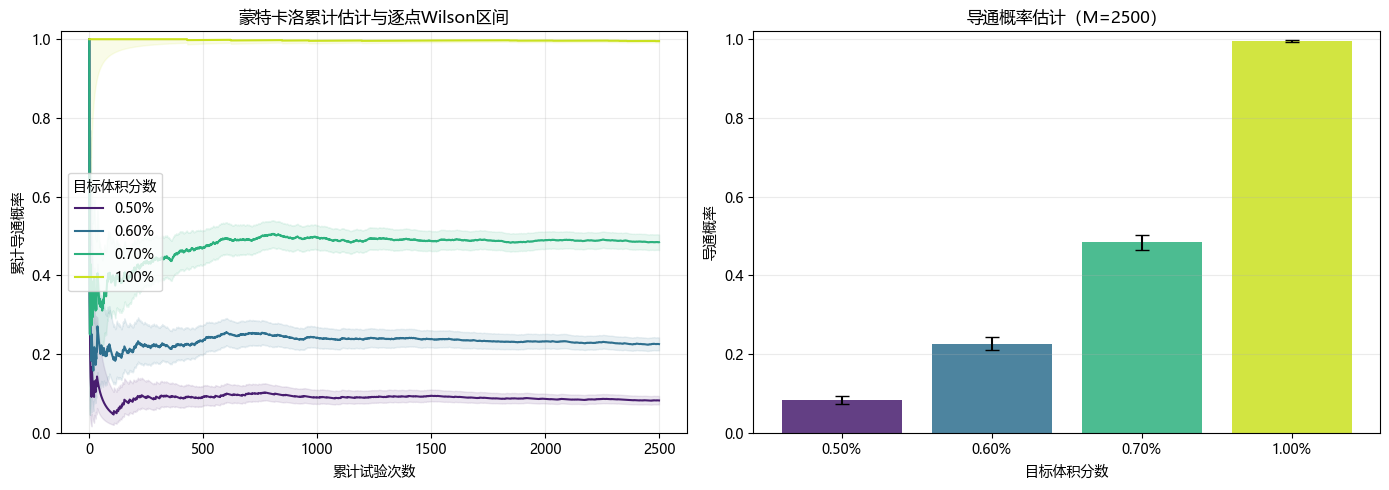

体积分数0.50%（354根）：P̂=0.0820，95% Wilson区间=[0.0719, 0.0934]
体积分数0.60%（424根）：P̂=0.2252，95% Wilson区间=[0.2093, 0.2420]
体积分数0.70%（495根）：P̂=0.4840，95% Wilson区间=[0.4644, 0.5036]
体积分数1.00%（707根）：P̂=0.9952，95% Wilson区间=[0.9916, 0.9973]


In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

running_successes = np.cumsum(trial_indicators, axis=0)
running_probability = running_successes / np.arange(1, N_TRIALS+1)[:, None]
running_low = np.empty_like(running_probability, dtype=float)
running_high = np.empty_like(running_probability, dtype=float)
for row in range(N_TRIALS):
    running_low[row], running_high[row] = wilson_interval(running_successes[row], row+1)

labels = [f"{100*x:.2f}%" for x in VOLUME_RATIO]
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(labels)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(1, N_TRIALS+1)
for column, (label, color) in enumerate(zip(labels, colors)):
    axes[0].plot(x, running_probability[:, column], color=color, label=label)
    axes[0].fill_between(x, running_low[:, column], running_high[:, column], color=color, alpha=0.10)
axes[0].set_xlabel("累计试验次数")
axes[0].set_ylabel("累计导通概率")
axes[0].set_ylim(0, 1.02)
axes[0].set_title("蒙特卡洛累计估计与逐点Wilson区间")
axes[0].grid(alpha=0.25)
axes[0].legend(title="目标体积分数")

positions = np.arange(len(labels))
errors = np.vstack((probability-ci_low, ci_high-probability))
axes[1].bar(positions, probability, color=colors, alpha=0.85)
axes[1].errorbar(positions, probability, yerr=errors, fmt="none", ecolor="black", capsize=5)
axes[1].set_xticks(positions, labels)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("目标体积分数")
axes[1].set_ylabel("导通概率")
axes[1].set_title(f"导通概率估计（M={N_TRIALS}）")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

for ratio, count, p_hat, low, high in zip(100*VOLUME_RATIO, n_cylinders, probability, ci_low, ci_high):
    print(f"体积分数{ratio:.2f}%（{count}根）：P̂={p_hat:.4f}，95% Wilson区间=[{low:.4f}, {high:.4f}]")

## 第二问结论与使用说明

- 正式答案以 1.8 nm 阈值、2500 次固定样本和上表 Wilson 区间为准；累计区间带是逐点区间，不是整条曲线的同时置信带。
- 表格保留四位小数是为了统一展示，并不表示蒙特卡洛精度达到四位小数；精度应由 Wilson 区间宽度判断。
- 体积分数按完整原圆柱的名义体积计算，裁成多个碎片后仍只计一次；题目允许重叠，所以没有扣除重叠体积。
- `fallbacks`、`dykstra_retries`、`projection_recoveries`、`stability_accepts` 和 `near_threshold` 用于审计纯原问题数值过程。若出现未解决支持点或 GJK 最大迭代，代码会携带试验编号中止，不会换种子重抽或静默记为不导通。
- `projection_recoveries` 与 `stability_accepts` 记录已经成功完成的可行恢复/多初值一致性路径；在大量边界碎片中它们可以很常见，并不等于未解决错误。真正未解决时整个批次会中止，不能把该试验从概率分母中剔除。
- 若重新运行正式模拟，固定 `BASE_SEED` 后串行与并行使用完全相同的逐试验随机流；四档共同前缀降低档位比较的随机波动，但不改变各档概率。